We want to know if a cell has consistent tuning across conditions or between homing/escpae and explore

1. compute tuning
2. compute linear sift tuning 
3. if curve is significant in both conditions
4. bootstrap for similarity metric (subsample many times from both the homing and exploration period and compute the firing by distance. Then I take pairs of subsampled tuning curves and compute some metric of similarity (e.g. difference in the preferred distance or cosine similarity) and that gives me a whole distribution of the metrics. If 0 falls outside the 95% of that distribution then the two curves are different.) 

In [4]:
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip4_21mar
exp = JAL6_flip4_21mar

In [ ]:
%load_ext autoreload
from JR_test_scripts.escape.functions.escape_utils import load, load_homing, firing_by_bin, smooth_firing_by_bin_by_trial
from behave_analysis.utils.creating_directories import make_directory
from JR_test_scripts.escape.functions.escape_data_loading_funcs import extract_homing_and_escape_periods
from JR_test_scripts.escape.functions.escape_tuning_funcs import single_trial_tuning, gaussian_fitting
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.analyze.stats.linshit import LinearShift
from behave_analysis.utils.PersistentPool import PersistentPool
from scipy.ndimage import gaussian_filter1d

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
"""Make plots for the neurons using their gaussian fitted tuning curves for sorting. Compare across conditions!
Plot only neurons with xval tuning curves"""

%autoreload 2
# compression_var = ['y_pos', 'distance_shelter', 'escape', 'speed'] 
# [['full_distance_shelter','distance_shelter','distance_first_goal'],['escape', 'escape_shelter', 'escape_first_goal']]
# compression_var = ['bird_dist_shelter','bird_dist_first_goal']
compression_var = ['escape']
# load data
session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
ons, offs, homie = load_homing(session, len(behave))
for comp in compression_var:
    
    nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
    dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/"+nickname)
    var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, comp, ons, offs, no_stationary = False, return_escape = True)
    
    # compute xval tuning during homing/escape
    mat_by_cond = single_trial_tuning(escape_matrix, var, cond, h_start)

2025-01-27 10:07:40.608 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [227]:
"""Linear shift significance for tuning curves
THIS IS THE GOOD ONE!!"""

# initialize vars
bins = int(np.amax(var)+1)
ons, offs, homie = load_homing(session, len(behave))

"""Compute real statistics (on the full session)"""

# the real stat
var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, 
                                                                                 frame_by_cluster_matrix, 
                                                                                 behave, 
                                                                                 y_pos, x_pos, 
                                                                                 bar, 
                                                                                 barflip, 
                                                                                 comp, 
                                                                                 ons, offs, 
                                                                                 no_stationary = False, 
                                                                                 return_escape = True)
    
# compute xval tuning during homing/escape
mat_by_cond = single_trial_tuning(escape_matrix, var, cond, h_start)

# initialize variables for output
y_fitted_full = np.zeros((len(mat_by_cond), frame_by_cluster_matrix.shape[1], bins)) # conditions x neurons x n_bins
R_full = np.zeros((frame_by_cluster_matrix.shape[1], len(mat_by_cond))) # neurons x conditions
fr_full = np.zeros((len(mat_by_cond), frame_by_cluster_matrix.shape[1], bins)) # conditions x neurons x n_bins
mu_full = np.zeros((frame_by_cluster_matrix.shape[1], len(mat_by_cond)))

for neuron in np.arange(np.shape(frame_by_cluster_matrix)[1]):
    for condition in np.arange(len(mat_by_cond)):

        # process the firing by bin for each trial for this neuron in this 
        matrix = mat_by_cond[condition][neuron,:,:]
        distances, smoothed_firing_rates, shift_constant, smooth_test = smooth_firing_by_bin_by_trial(matrix, fr_all_time = [], method = 'across_trials')
        R, y, params, double_wins = gaussian_fitting(smoothed_firing_rates[~np.isnan(smoothed_firing_rates)], np.arange(np.sum(~np.isnan(smoothed_firing_rates))), verbose = False)
        y_fitted = np.full_like(smoothed_firing_rates, np.nan)
        y_fitted[~np.isnan(smoothed_firing_rates)] = y

        # dump parameters into the variables to return
        R_full[neuron, condition] = R
        mu_full[neuron, condition] = params[1]
        y_fitted_full[condition, neuron, :len(y_fitted)] = y_fitted
        fr_full[condition, neuron, :len(smoothed_firing_rates)] = smoothed_firing_rates

"""Compute real statistics (on the central third of each condition)"""

# setting up the shifts
T = np.shape(frame_by_cluster_matrix)[0]
central_chunk = T/3
N = int((T - central_chunk)/2)
min_step = 120
step = 400
step_n = 100
shifts_one_sided = np.arange(min_step,min_step+((step_n/2)*step), step)

shelter = np.where(bar == True)[0][0]
bar_in = np.where(barflip == True)[0][0]
mid_shelter = [int(shelter/3), int((shelter/3)*2)]
mid_bar = [int(shelter+((bar_in - shelter)/3)), int(shelter+(((bar_in - shelter)/3)*2))]
mid_flip = [int(bar_in+((len(bar) - bar_in)/3)), int(bar_in+(((len(bar) - bar_in)/3)*2))]
shift_vector = np.zeros(len(bar))
shift_vector[mid_shelter[0]:mid_shelter[1]] = 1
shift_vector[mid_bar[0]:mid_bar[1]] = 1
shift_vector[mid_flip[0]:mid_flip[1]] = 1
shift_vector = shift_vector.astype(bool)

# make sure we're not shifting our of range
shifts_left = shifts_one_sided[shifts_one_sided < mid_shelter[0]]
shifts_right = shifts_one_sided[(shifts_one_sided + mid_flip[1]) < len(bar)]
# now double them so we go in both directions
shifts = np.sort(np.hstack((shifts_right,-shifts_left)))

# the real stat
var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, 
                                                                                frame_by_cluster_matrix[shift_vector,:], 
                                                                                behave[shift_vector], 
                                                                                y_pos[shift_vector], 
                                                                                x_pos[shift_vector], 
                                                                                bar[shift_vector], # should this also be shifted?!?! 
                                                                                barflip[shift_vector], 
                                                                                comp, 
                                                                                ons, offs, shift_vector, 
                                                                                no_stationary = False, 
                                                                                return_escape = True)
    
# compute xval tuning during homing/escape
mat_by_cond = single_trial_tuning(escape_matrix, var, cond, h_start)

# initialize variables for output
y_fitted_real = np.zeros((len(mat_by_cond), frame_by_cluster_matrix.shape[1], bins)) # conditions x neurons x n_bins
R_real = np.zeros((frame_by_cluster_matrix.shape[1], len(mat_by_cond))) # neurons x conditions
fr_real = np.zeros((len(mat_by_cond), frame_by_cluster_matrix.shape[1], bins)) # conditions x neurons x n_bins
mu_real = np.zeros((frame_by_cluster_matrix.shape[1], len(mat_by_cond)))

for neuron in np.arange(np.shape(frame_by_cluster_matrix)[1]):
    for condition in np.arange(len(mat_by_cond)):

        # process the firing by bin for each trial for this neuron in this 
        matrix = mat_by_cond[condition][neuron,:,:]
        distances, smoothed_firing_rates, shift_constant, smooth_test = smooth_firing_by_bin_by_trial(matrix, fr_all_time = [], method = 'across_trials')
        R, y, params, double_wins = gaussian_fitting(smoothed_firing_rates[~np.isnan(smoothed_firing_rates)], np.arange(np.sum(~np.isnan(smoothed_firing_rates))), verbose = False)
        y_fitted = np.full_like(smoothed_firing_rates, np.nan)
        y_fitted[~np.isnan(smoothed_firing_rates)] = y

        # dump parameters into the variables to return
        R_real[neuron, condition] = R
        mu_real[neuron, condition] = params[1]
        y_fitted_real[condition, neuron, :len(y_fitted)] = y_fitted
        fr_real[condition, neuron, :len(smoothed_firing_rates)] = smoothed_firing_rates

"""Compute shifted statistics"""

# initialize variables for output
y_fitted_shift = np.zeros((len(shifts),3, frame_by_cluster_matrix.shape[1], bins)) # conditions x neurons x n_bins
R_shift = np.zeros((len(shifts),frame_by_cluster_matrix.shape[1], 3)) # neurons x conditions
mu_shifts = np.zeros((len(shifts),frame_by_cluster_matrix.shape[1], 3)) # neurons x conditions
fr_shift = np.zeros((len(shifts),3, frame_by_cluster_matrix.shape[1], bins))

for s_idx, s in enumerate(shifts):
    shifted_vec = np.roll(shift_vector,int(s))
    var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, 
                                                                                    frame_by_cluster_matrix[shift_vector,:], 
                                                                                    behave[shifted_vec], 
                                                                                    y_pos[shifted_vec], 
                                                                                    x_pos[shifted_vec], 
                                                                                    bar[shifted_vec], # should this also be shifted?!?! 
                                                                                    barflip[shifted_vec], 
                                                                                    comp, 
                                                                                    ons, offs, shifted_vec, 
                                                                                    no_stationary = False, 
                                                                                    return_escape = True)

    mat_by_cond = single_trial_tuning(escape_matrix, var, cond, h_start)
    for neuron in np.arange(np.shape(frame_by_cluster_matrix)[1]):
        for condition in np.arange(len(mat_by_cond)):

            # process the firing by bin for each trial for this neuron in this 
            matrix = mat_by_cond[condition][neuron,:,:]
            distances, smoothed_firing_rates, shift_constant, smooth_test = smooth_firing_by_bin_by_trial(matrix, fr_all_time = [], method = 'across_trials')
            R, y, params, double_wins = gaussian_fitting(smoothed_firing_rates[~np.isnan(smoothed_firing_rates)], np.arange(np.sum(~np.isnan(smoothed_firing_rates))), verbose = False)
            y_fitted = np.full_like(smoothed_firing_rates, np.nan)
            y_fitted[~np.isnan(smoothed_firing_rates)] = y

            # dump parameters into the variables to return
            R_shift[s_idx, neuron, condition] = R
            mu_shifts[s_idx, neuron, condition] = params[1]
            y_fitted_shift[s_idx, condition, neuron, :len(y_fitted)] = y_fitted
            fr_shift[s_idx, condition, neuron, :len(smoothed_firing_rates)] = smoothed_firing_rates

2025-01-29 11:13:52.605 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [ ]:
"""Plot linear shift and real stats"""
%matplotlib inline
condition = [0,1,2]
colors = ['#228B22','#FF8C00','#008B8B']
c_names = ['shelter_only', 'barrier', 'barrier_flipped']
nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/"+nickname)

for neuron in np.arange(np.shape(frame_by_cluster_matrix)[1]):
    fig, axs = plt.subplots(3,3,figsize = (12,12))
    for c in condition:
        axs[c,0].plot(y_fitted_shift[:,c,neuron,:].T,'k', alpha = .3)
        axs[c,0].plot(y_fitted_real[c,neuron,:],color = colors[c], linewidth = 3)
        # axs[c,0].plot(fr_shift[:,c,neuron,:].T,'k', alpha = .3)
        # axs[c,0].plot(fr_real[c,neuron,:],color = colors[c], linewidth = 3)
        axs[c,0].set_title(c_names[c])
        axs[c,0].set_ylabel('Firing rate')
        axs[c,0].set_xlabel(comp)

        axs[c,1].hist(mu_shifts[:,neuron,c], edgecolor = None, facecolor = 'k', alpha = .3)
        yl = axs[c,1].get_ylim()
        axs[c,1].plot([mu_real[neuron, c],mu_real[neuron, c]],yl,color = colors[c])
        axs[c,1].set_title('Comparing mean of fitted gaussian')
        axs[c,1].set_xlabel(comp)
        axs[c,1].set_ylabel('Linear shifts')

        axs[c,2].hist(R_shift[:,neuron,c], edgecolor = None, facecolor = 'k', alpha = .3)
        yl = axs[c,1].get_ylim()
        axs[c,2].plot([R_real[neuron, c],R_real[neuron, c]],yl,color = colors[c])
        axs[c,2].set_title('Comparing goodness of gaussian fit\n95th perc. sig: ' + str(R_real[neuron,c] > np.percentile(R_shift[:,neuron,c],95)) + ', 99th perc. sig: ' + str(R_real[neuron,c] > np.percentile(R_shift[:,neuron,c],99)))
        axs[c,2].set_xlabel('R^2')
        axs[c,2].set_ylabel('Linear shifts')

    plt.tight_layout()
    fig.savefig(dump_path + "/neuron" + str(neuron) + "_linshit.png")
    plt.close()

How to compare cells with significant tuning curves!?
- for a given condition, pull out the significant ones: do they tile the space?
- sig cells are found using the fits for the central third, plotting is done with the full fits
- pull out neurons that are significant in more than one condition: compare their tuning! mu? cosine similarity?

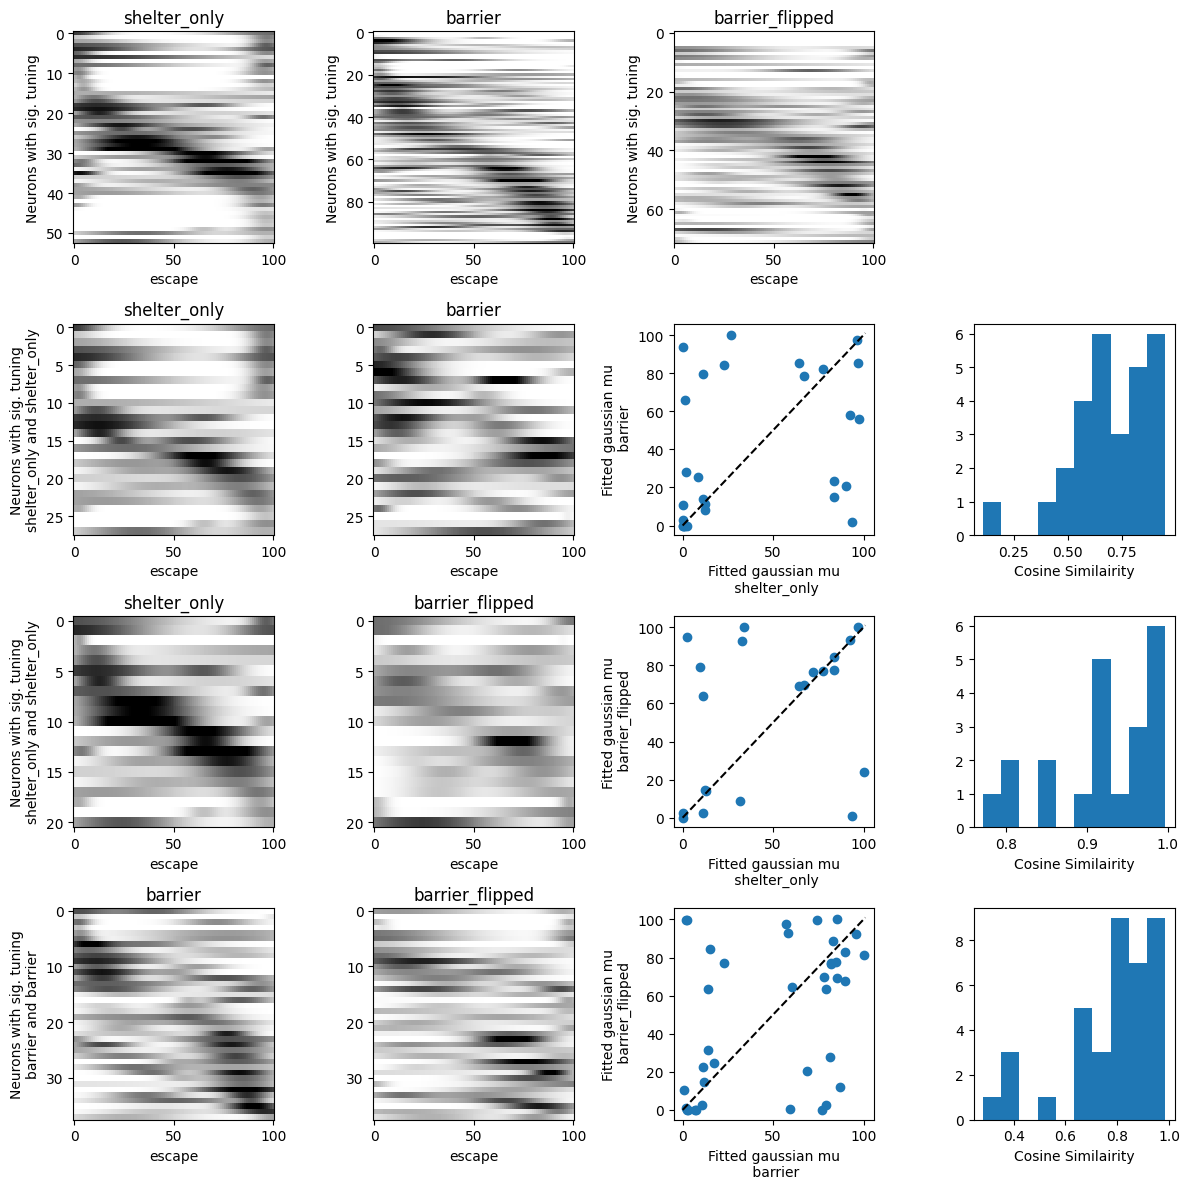

In [247]:
from sklearn.metrics.pairwise import cosine_similarity
condition = [0,1,2]
c_names = ['shelter_only', 'barrier', 'barrier_flipped']
fig, axs = plt.subplots(4,4,figsize = (12,12))

# top row: the significant neurons in each condition (from linshit)
for c in condition:
    sig_this_c = R_real[:,c] > np.percentile(R_shift[:,:,c],95, axis = 0)
    sig_fit = y_fitted_full[c,sig_this_c,:]
    sig_mu = mu_full[sig_this_c,c]
    axs[0,c].imshow(sig_fit[np.argsort(sig_mu),:], cmap="gray_r", vmin = 0, vmax = 1.5, aspect="auto", interpolation = "none")
    axs[0,c].set_title(c_names[c])
    axs[0,c].set_ylabel('Neurons with sig. tuning')
    axs[0,c].set_xlabel(comp)
fig.delaxes(axs[0, 3])

# rows 1-3: tuning of neurons significant in more than one condition
comp_c = [[0,0,1],[1,2,2]]
for c in condition:
    sig_intersect = np.logical_and(R_real[:,comp_c[0][c]] > np.percentile(R_shift[:,:,comp_c[0][c]],95, axis = 0),
                    R_real[:,comp_c[1][c]] > np.percentile(R_shift[:,:,comp_c[1][c]],95, axis = 0))
    sig_fit1 = y_fitted_full[comp_c[0][c],sig_intersect,:]
    sig_fit2 = y_fitted_full[comp_c[1][c],sig_intersect,:]
    sig_mu1 = mu_full[sig_intersect,comp_c[0][c]]
    sig_mu2 = mu_full[sig_intersect,comp_c[1][c]]
    # show the tuning curves
    axs[c+1,0].imshow(sig_fit1[np.argsort(sig_mu1),:], cmap="gray_r", vmin = 0, vmax = 1.5, aspect="auto", interpolation = "none")
    axs[c+1,0].set_title(c_names[comp_c[0][c]])
    axs[c+1,0].set_ylabel('Neurons with sig. tuning\n' + c_names[comp_c[0][c]] + ' and ' + c_names[comp_c[0][c]])
    axs[c+1,0].set_xlabel(comp)
    axs[c+1,1].imshow(sig_fit2[np.argsort(sig_mu1),:], cmap="gray_r", vmin = 0, vmax = 1.5, aspect="auto", interpolation = "none")
    axs[c+1,1].set_title(c_names[comp_c[1][c]])
    axs[c+1,1].set_xlabel(comp)
    # compare mu
    axs[c+1,2].plot([0,sig_fit1.shape[1]],[0,sig_fit1.shape[1]],'--k')
    axs[c+1,2].scatter(sig_mu1,sig_mu2)
    axs[c+1,2].set_xlabel('Fitted gaussian mu\n ' + c_names[comp_c[0][c]])
    axs[c+1,2].set_ylabel('Fitted gaussian mu\n ' + c_names[comp_c[1][c]])
    # cosine similarity
    cos_sim = cosine_similarity(sig_fit1, sig_fit2, dense_output=True) 
    cos_sim_diag = np.diag(cos_sim)
    axs[c+1,3].hist(cos_sim_diag)
    axs[c+1,3].set_xlabel('Cosine Similairity')

plt.tight_layout()

In [245]:
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(sig_fit1, sig_fit2, dense_output=True) 
cos_sim_diag = np.diag(cos_sim)

idx = 2
print(cos_sim_diag[idx], cosine_similarity(sig_fit1[idx,:].reshape(1, -1),sig_fit2[idx,:].reshape(1, -1))[0,0])

0.9382144002954229 0.9382144002954231


In [ ]:
"""Linear shift significance for tuning curves
This method shifts after creating the escape_matrix - NOT the ideal approach
DEPRECATED"""
neuron = 17
condition = 0

bins = int(np.amax(var)+1)
X = escape_matrix[neuron,cond == condition]
this_cond = cond[cond == condition]
cond_start = [x for x in h_start if cond[x] == condition]
central_y = var[cond == condition]
n_central_homies = np.floor(len(cond_start)/3).astype(int)
central_chunk = [cond_start[n_central_homies+1], cond_start[(n_central_homies*2)+1]] # the indices for the beginning and end of the chunk we're actually using
central_start = cond_start[n_central_homies+1:(n_central_homies*2)+2] # the indices for the start of homings in the chunk we're using
central_start = [x - central_start[0] for x in central_start]

# set up shifts
min_step = 40
step_size = min_step*3
# ensure 0 step is not included (thanks to min step away from the 0 stat!)
shifts_left = - np.arange(min_step, central_chunk[0], step_size)
shifts_right = np.arange(min_step, len(X) - central_chunk[1], step_size)
# now double them so we go in both directions
shifts = np.sort(np.hstack((shifts_left,shifts_right)))

all_fr = np.full((len(shifts),bins), np.nan)
all_R = np.full(len(shifts), np.nan)

for idx, s in enumerate(shifts):

    # take only the central chunk!
    y = central_y[int(s + central_chunk[0]) : int(s + central_chunk[1])]
    n = X[central_chunk[0]:central_chunk[1]]

    # extract firing per bin for each shift
    matrix = np.full((len(central_start),bins), np.nan)
    # iterate through trials, pull out firing by bin
    for tr, _ in enumerate(central_start[:-1]):
        neur = X[central_start[tr]:central_start[tr+1]]
        v = y[central_start[tr]:central_start[tr+1]]
        matrix[tr,:] = firing_by_bin(v.astype(int), neur, bins, remove_empty = False)

    # smooth activity on each trial
    # remove trials that are all nan
    all_nan_rows = np.all(np.isnan(matrix), axis=1)
    all_test = matrix[~all_nan_rows,:]
    smooth_test = np.full_like(matrix, np.nan)
    for sidx, sxm in enumerate(matrix):
        this_line = np.full_like(sxm, np.nan)
        where_nan = np.isnan(sxm)
        this_line[~where_nan] = gaussian_filter1d(sxm[~where_nan], 3)
        smooth_test[sidx,:] = this_line

    # get median firing across trials
    all_nan_cols = np.all(np.isnan(smooth_test), axis=0)
    smoothed_firing_rates = np.full(len(all_nan_cols), np.nan)
    smoothed_firing_rates[~all_nan_cols] = np.nanmedian(smooth_test[:,~all_nan_cols], axis = 0)

    # make firing rates positive
    shift_constant = abs(np.nanmin(smoothed_firing_rates))+ 1e-6 # Add a small epsilon to avoid exact zero
    smoothed_firing_rates = smoothed_firing_rates + shift_constant
    distances = np.arange(len(smoothed_firing_rates))

    R, y, params, double_wins = gaussian_fitting(smoothed_firing_rates[~np.isnan(smoothed_firing_rates)], np.arange(np.sum(~np.isnan(smoothed_firing_rates))), verbose = False)
    all_R[idx] = R
    all_fr[idx,:] = smoothed_firing_rates